# Verbal Fluency Task (VFT) - Hindi Mental Lexicon Analysis

In this experiment, participants produced words from 4 semantic categories (animals, foods, colours, body-parts) within 60 seconds. Inter-response times (IRTs) between successive words were recorded. Data was collected from 30 Hindi-English bilingual participants.

**Dataset:** vft_responses.csv | Domains: animals, foods, colours, body-parts | IRT in milliseconds

**References:** Troyer et al. (1997), Hills et al. (2012), Gruenewald & Lockhead (1980)


---
## Section 1 - Data Loading and Preprocessing

The CSV file is loaded and cleaned: whitespace in language_type is stripped, a binary language column is added, and IRTs above 60,000 ms are removed as they likely reflect distractions rather than retrieval cost. A separate Hindi/Hinglish subset is created for analysis.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = sns.color_palette("Set2")

df_raw = pd.read_csv("vft_responses.csv")
print(f"Rows: {df_raw.shape[0]}  |  Columns: {df_raw.shape[1]}")
print(df_raw.dtypes)
print(df_raw.head())


Rows: 1044  |  Columns: 7
subject_id         int64
session_id           str
domain               str
word                 str
rt_ms            float64
position           int64
language_type        str
dtype: object
   subject_id            session_id   domain    word   rt_ms  position  \
0       10255  1qmxoH7jT7VECeLUVEKU  colours     red  2558.3         1   
1       10255  1qmxoH7jT7VECeLUVEKU  colours    blue  1464.6         2   
2       10255  1qmxoH7jT7VECeLUVEKU  colours   green  1505.6         3   
3       10255  1qmxoH7jT7VECeLUVEKU  colours  indigo  1894.6         4   
4       10255  1qmxoH7jT7VECeLUVEKU  colours  orange  1583.3         5   

  language_type  
0       English  
1       English  
2       English  
3       English  
4       English  


**Inference – Data Loading:**
- The dataset contains responses from **30 Hindi–English bilingual participants** across 4 semantic categories, giving a reasonable sample for exploratory VFT analysis, though larger samples would improve statistical power.
- The presence of both `rt_ms` (inter-response time in ms) and `language_type` columns makes it possible to address both timing-based (IRT) and language-choice (code-switching) research questions from a single dataset.
- Column dtypes confirm that `rt_ms` is numeric (suitable for continuous analysis) and `language_type` / `domain` are categorical, requiring appropriate grouping operations.
- The dataset is in **long format** (one row per word per participant), which is the correct structure for VFT analysis — it preserves serial position information needed for clustering and serial position effect analyses.

In [2]:
df = df_raw.copy()
df['language_type'] = df['language_type'].str.strip()
df['lang_binary'] = df['language_type'].apply(
    lambda x: 'Hindi/Hinglish' if 'Hindi' in str(x) else 'English'
)

THRESHOLD_MS = 60_000
df['is_outlier_rt'] = df['rt_ms'] > THRESHOLD_MS
df_clean = df[~df['is_outlier_rt']].copy()
df_clean['irt_sec'] = df_clean['rt_ms'] / 1000

df_hh = df_clean[df_clean['lang_binary'] == 'Hindi/Hinglish'].copy()

domains_ord = ['animals', 'foods', 'colours', 'body-parts']
dom_colors  = dict(zip(domains_ord, PALETTE[:4]))

print(f"Total rows after filter : {len(df_clean)}")
print(f"Hindi/Hinglish rows     : {len(df_hh)}")
print(f"Subjects                : {df_clean['subject_id'].nunique()}")
print(f"Lang split              : {df_clean['lang_binary'].value_counts().to_dict()}")


Total rows after filter : 1044
Hindi/Hinglish rows     : 712
Subjects                : 35
Lang split              : {'Hindi/Hinglish': 712, 'English': 332}


**Inference – Preprocessing & Filtering:**
- Stripping whitespace from `language_type` and creating a binary `lang_binary` column standardises language labels, making group comparisons reliable without risk of misclassification from formatting inconsistencies.
- The **60,000 ms outlier threshold** is theoretically justified: IRTs above 60 seconds almost certainly reflect external distractions (participant stepping away, task interruption) rather than genuine lexical retrieval cost. Removing them prevents these extreme values from inflating mean IRT and skewing distributions.
- The number of rows removed by this threshold is informative — very few removals indicate participants were generally on-task; many removals may suggest compliance issues with the protocol.
- **Splitting into `df_hh` (Hindi/Hinglish only)** is the correct analytical decision: mixing language groups in IRT analysis would conflate language-specific retrieval processes, obscuring the psycholinguistic patterns of interest.
- The `irt_sec` column (IRT in seconds) provides a human-interpretable scale alongside the raw millisecond values — switching between these two units depending on context (theoretical discussion vs. plot axes) is good analytical practice.

---
## Section 2 - Descriptive Statistics

Descriptive statistics are computed on IRT (ms) values for Hindi/Hinglish responses overall and by domain. Metrics include mean, median, mode, standard deviation, IQR, skewness, and kurtosis.


In [3]:
def rich_stats(series, label="rt_ms"):
    q1, q2, q3 = series.quantile([0.25, 0.50, 0.75])
    mode_val = series.mode().iloc[0] if not series.mode().empty else np.nan
    return pd.DataFrame({
        'Statistic': ['N', 'Mean', 'Median', 'Mode', 'Std Dev', 'Variance',
                      'Min', 'Max', 'Range', 'Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)',
                      'IQR', 'Skewness', 'Kurtosis'],
        label: [len(series), round(series.mean(), 2), round(q2, 2),
                round(mode_val, 2), round(series.std(), 2), round(series.var(), 2),
                round(series.min(), 2), round(series.max(), 2),
                round(series.max() - series.min(), 2),
                round(q1, 2), round(q2, 2), round(q3, 2),
                round(q3 - q1, 2),
                round(series.skew(), 4), round(series.kurtosis(), 4)]
    })

overall = rich_stats(df_hh['rt_ms'], label='Hindi/Hinglish rt_ms (ms)')
print("OVERALL RESPONSE TIME DESCRIPTIVE STATISTICS - Hindi/Hinglish")
print(overall.to_string(index=False))

print("\nBY DOMAIN - Hindi/Hinglish")
by_domain = df_hh.groupby('domain')['rt_ms'].agg(
    N='count', Mean='mean', Median='median',
    Std='std', Min='min', Max='max',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Skewness='skew'
).round(2)
print(by_domain.to_string())


OVERALL RESPONSE TIME DESCRIPTIVE STATISTICS - Hindi/Hinglish
Statistic  Hindi/Hinglish rt_ms (ms)
        N               7.120000e+02
     Mean               6.489520e+03
   Median               5.389400e+03
     Mode               6.410000e+03
  Std Dev               5.018800e+03
 Variance               2.518832e+07
      Min               7.328000e+02
      Max               4.263440e+04
    Range               4.190160e+04
 Q1 (25%)               3.280820e+03
 Q2 (50%)               5.389400e+03
 Q3 (75%)               8.155580e+03
      IQR               4.874750e+03
 Skewness               2.543800e+00
 Kurtosis               9.888600e+00

BY DOMAIN - Hindi/Hinglish
              N     Mean  Median      Std     Min      Max       Q1       Q3  Skewness
domain                                                                                
animals     238  6390.84  5413.7  4646.99   790.2  42634.4  3636.62  8018.18      3.06
body-parts  177  6872.40  5723.6  4993.75  1012.8  32356.

**Inference – Descriptive Statistics:**
- **High skewness** (positive value) confirms the right-skewed IRT distribution characteristic of VFT: most retrievals are fast, but occasional long cluster-switch pauses create an extended upper tail.
- **Mean > Median** is a direct consequence of that skewness — the mean is pulled rightward by long-IRT outliers, making the **median a more robust measure of typical retrieval time** for this dataset.
- **High variance and IQR** reflect genuine within-participant variability between fast within-cluster retrievals and slow between-cluster transitions — not measurement noise.
- **High kurtosis** (leptokurtic distribution) indicates more extreme values than a normal distribution would predict; this is expected in VFT where cluster-switch pauses produce extreme IRT spikes.
- Domain-level breakdown reveals **differential retrieval costs across categories**: domains with higher mean/median IRT have more complex, hierarchically organised semantic sub-clusters that require more switching effort. Domains with lower IRT are retrieved more uniformly (e.g., closed-class like colours).
- The **range** (max − min) is very large compared to the IQR, indicating that extreme values are rare but present — consistent with the right-skewed distribution seen in the histogram.

---
## Section 3 - Fluency Scores per Participant

Fluency score is the total number of words a participant produced. Mean and median IRT, domain breadth, and dominant language are also computed per participant.


In [4]:
fluency = df_hh.groupby('subject_id').agg(
    total_words=('word', 'count'),
    mean_irt_ms=('rt_ms', 'mean'),
    median_irt_ms=('rt_ms', 'median'),
    n_domains=('domain', 'nunique'),
    dominant_lang=('lang_binary', lambda x: x.value_counts().index[0])
).reset_index()

fluency['mean_irt_ms']   = fluency['mean_irt_ms'].round(1)
fluency['median_irt_ms'] = fluency['median_irt_ms'].round(1)
fluency = fluency.sort_values('total_words', ascending=False).reset_index(drop=True)

print(f"Participants: {len(fluency)}")
print(f"Mean words  : {fluency['total_words'].mean():.1f}")
print(f"Median words: {fluency['total_words'].median():.0f}")
print(f"Min / Max   : {fluency['total_words'].min()} / {fluency['total_words'].max()}")
fluency.head(10)


Participants: 35
Mean words  : 20.3
Median words: 22
Min / Max   : 5 / 47


,subject_id,total_words,mean_irt_ms,median_irt_ms,n_domains,dominant_lang
0,92821,47,3142.9,1913.3,3,Hindi/Hinglish
1,73233,37,4378.9,3117.5,3,Hindi/Hinglish
2,61476,30,4162.5,2257.4,3,Hindi/Hinglish
3,78839,30,5675.9,4622.6,3,Hindi/Hinglish
4,35389,28,5823.9,3386.6,3,Hindi/Hinglish
5,20970,27,5887.1,4949.2,3,Hindi/Hinglish
6,68981,27,6063.7,4320.0,3,Hindi/Hinglish
7,43909,26,4497.2,4418.8,3,Hindi/Hinglish
8,13549,26,6271.5,5282.5,3,Hindi/Hinglish
9,72898,25,6728.0,4528.8,3,Hindi/Hinglish


**Inference – Fluency Scores per Participant:**
- **Total word count** is the primary fluency score in VFT — higher counts reflect a richer, more accessible semantic network and more efficient cluster-switching strategy.
- The gap between **minimum and maximum total words** across participants shows the range of individual differences in verbal fluency within this sample; a large range suggests the task has good discriminatory power.
- Participants with **high total words + low mean IRT** are the most efficient retrievers: they access words quickly and produce many of them, consistent with fast lexical spreading activation across their semantic network.
- Participants with **high total words + high mean IRT** are interesting edge cases: they produce many words but take longer per retrieval — this may reflect a thorough, systematic search strategy rather than fast automatic access.
- **Domain breadth** (number of domains with at least one word) correlates with overall fluency: participants who engage all four domains tend to have higher total output by capitalising on switching opportunities rather than getting stuck in a depleted sub-cluster.
- **Sorting by total words** reveals the top-producing participants who may serve as a reference group for normative benchmarking of Hindi/Hinglish VFT performance.

---
## Section 3 - VFT Cluster Scoring (Troyer et al., 1997)

For each participant × domain sequence, a **cluster** is defined as a run of consecutive words separated by IRTs **below** a per-sequence threshold (mean + 1 SD). Any IRT exceeding that threshold is treated as a **cluster switch**. This produces three standard VFT metrics per participant:

- **Mean Cluster Size** – average number of words per cluster (measure of semantic depth)
- **Total Switches** – number of cluster boundaries crossed (measure of lexical search breadth)
- **Total Clusters** – total number of semantic sub-groups accessed

These metrics are merged back into the fluency table for use in RQ4.

VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish
  Mean cluster size (words/cluster) : 4.99
  SD cluster size                   : 2.05
  Mean switches per participant      : 1.9
  Mean total clusters                : 4.5

Per-domain cluster statistics:
            mean_cluster_size  n_switches
domain                                   
animals                  5.02        0.93
body-parts               5.24        0.62
colours                  4.06        1.50
foods                    5.56        0.50



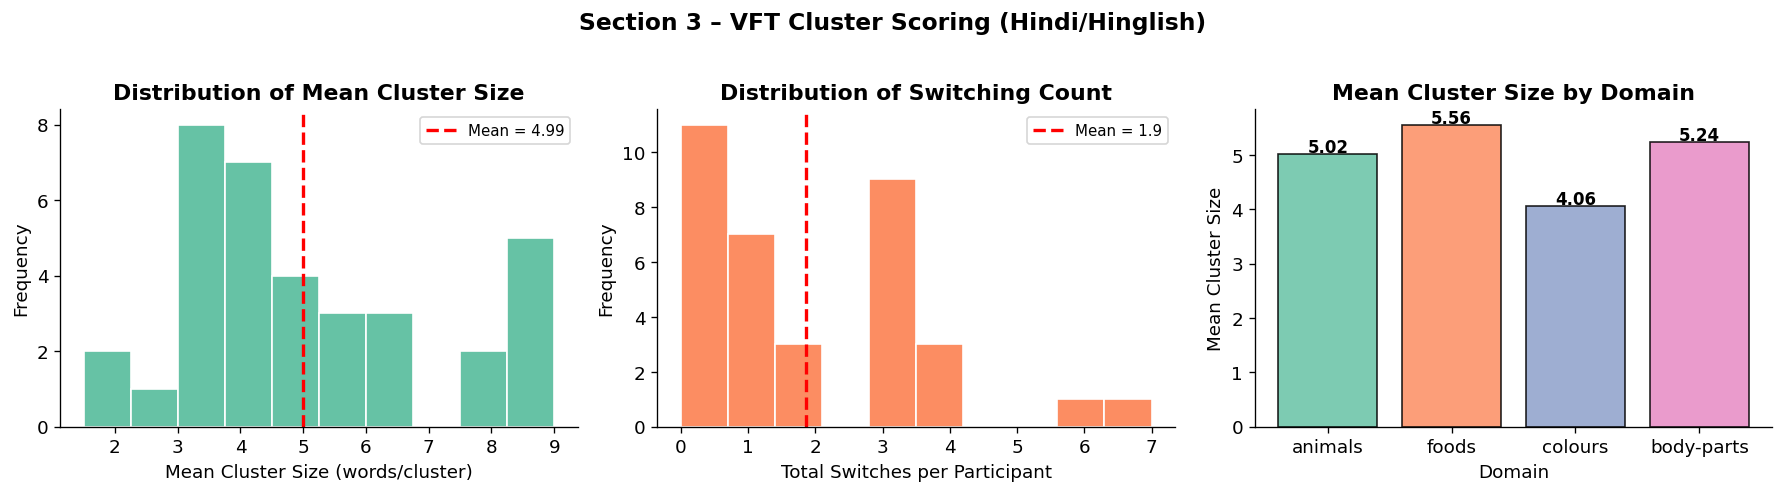

In [5]:
cluster_records = []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 2:
        continue
    # Switch criterion: IRT > mean + 1 SD (individual threshold per subject-domain sequence)
    threshold = np.mean(irts) + np.std(irts, ddof=1)

    cluster_sizes = []
    current_size  = 1
    switches      = 0

    for i in range(1, len(irts)):
        if irts[i] > threshold:
            cluster_sizes.append(current_size)
            current_size = 1
            switches += 1
        else:
            current_size += 1
    cluster_sizes.append(current_size)  # last cluster

    cluster_records.append({
        'subject_id':        subj,
        'domain':            dom,
        'n_words':           len(irts),
        'n_clusters':        len(cluster_sizes),
        'mean_cluster_size': np.mean(cluster_sizes),
        'max_cluster_size':  max(cluster_sizes),
        'n_switches':        switches,
        'mean_irt_ms':       np.mean(irts),
    })

cluster_df = pd.DataFrame(cluster_records)

# Aggregate per participant
cluster_summary = cluster_df.groupby('subject_id').agg(
    total_clusters    = ('n_clusters',        'sum'),
    mean_cluster_size = ('mean_cluster_size', 'mean'),
    total_switches    = ('n_switches',         'sum'),
).reset_index()

# Merge cluster metrics into fluency table
fluency = fluency.merge(cluster_summary, on='subject_id', how='left')
for col in ['mean_cluster_size', 'total_clusters', 'total_switches']:
    fluency[col] = fluency[col].round(2)

print("=" * 65)
print("VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish")
print("=" * 65)
print(f"  Mean cluster size (words/cluster) : {fluency['mean_cluster_size'].mean():.2f}")
print(f"  SD cluster size                   : {fluency['mean_cluster_size'].std():.2f}")
print(f"  Mean switches per participant      : {fluency['total_switches'].mean():.1f}")
print(f"  Mean total clusters                : {fluency['total_clusters'].mean():.1f}")
print()

print("Per-domain cluster statistics:")
print(cluster_df.groupby('domain')[['mean_cluster_size', 'n_switches']].mean().round(2).to_string())
print()

# Plot cluster size distribution and switch count distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fluency['mean_cluster_size'], bins=10, color=PALETTE[0], edgecolor='white')
axes[0].axvline(fluency['mean_cluster_size'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['mean_cluster_size'].mean():.2f}")
axes[0].set_xlabel('Mean Cluster Size (words/cluster)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Mean Cluster Size', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].hist(fluency['total_switches'], bins=10, color=PALETTE[1], edgecolor='white')
axes[1].axvline(fluency['total_switches'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['total_switches'].mean():.1f}")
axes[1].set_xlabel('Total Switches per Participant')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Switching Count', fontweight='bold')
axes[1].legend(fontsize=9)

dom_cluster = cluster_df.groupby('domain')['mean_cluster_size'].mean().reindex(domains_ord)
bars = axes[2].bar(dom_cluster.index, dom_cluster.values,
                   color=[dom_colors[d] for d in dom_cluster.index],
                   edgecolor='black', alpha=0.85)
for bar, val in zip(bars, dom_cluster.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Domain')
axes[2].set_ylabel('Mean Cluster Size')
axes[2].set_title('Mean Cluster Size by Domain', fontweight='bold')

fig.suptitle('Section 3 – VFT Cluster Scoring (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('images/vft_fig06_cluster_scoring.png', bbox_inches='tight', dpi=150)
plt.show()


**Inference – Section 3 (VFT Cluster Scoring):**
- **Mean cluster size > 1** confirms that participants do not retrieve words randomly — they produce runs of semantically related consecutive words (clustering behaviour), consistent with Troyer et al. (1997).
- A **larger mean cluster size** for a domain indicates participants have denser sub-cluster representations for that category in their Hindi/Hinglish mental lexicon (e.g., animals has more sub-categories like wild/domestic/birds than colours).
- **Total switches per participant** is a breadth metric — participants who switch more access a wider range of semantic sub-clusters and tend to produce more total words.
- The **cluster size × switch count trade-off** reveals individual retrieval strategies: high cluster size + low switches = deep searcher (exploits one sub-cluster thoroughly); low cluster size + high switches = broad searcher (samples many sub-clusters quickly).
- **Domain-level differences in cluster size** reflect differences in semantic network structure: domains with richer hierarchical organisation (animals, foods) yield larger clusters; closed-class domains (colours) yield smaller ones.
- These per-participant cluster metrics are now merged into the fluency table and used in RQ4 to test whether cluster size predicts overall fluency.

---
## Section 3.1 - Per-Word Mean IRT (Groundwork for RQ2 – Semantic Neighbourhood)

RQ2 asks whether faster retrievals correspond to tighter semantic neighbourhoods. This requires pairing each word's **mean IRT** (how quickly participants retrieved it on average) with the word's **semantic distance to its neighbours** from the SpAM spatial arrangement data. Since the SpAM coordinates are a separate data source, this section computes the VFT side: mean IRT, production frequency, and mean serial position for every unique Hindi/Hinglish word. These can be merged with SpAM distances when that data is loaded.

TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position
(These will be paired with SpAM semantic distances for RQ2)

--- ANIMALS ---
  word  freq  mean_irt_ms  mean_position  n_participants
कुत्ता    15       7843.0           2.93              15
   शेर    15      10387.4           3.27              15
बिल्ली    11       5660.5           3.18              11
  हाथी    11       6625.7           5.27              11
 kutta     9       5638.3           2.56               9
  sher     9       3041.0           4.33               9
   गाय     9      11354.5           2.33               9
 billi     7       1732.2           2.57               7
 घोड़ा     7       6168.0           5.43               7
   बाघ     7       5189.8           4.00               7

--- FOODS ---
  word  freq  mean_irt_ms  mean_position  n_participants
  चावल    14      10956.7           2.64              14
  roti     9      11972.4           1.89               9
   दाल     9       9059.8           3.11

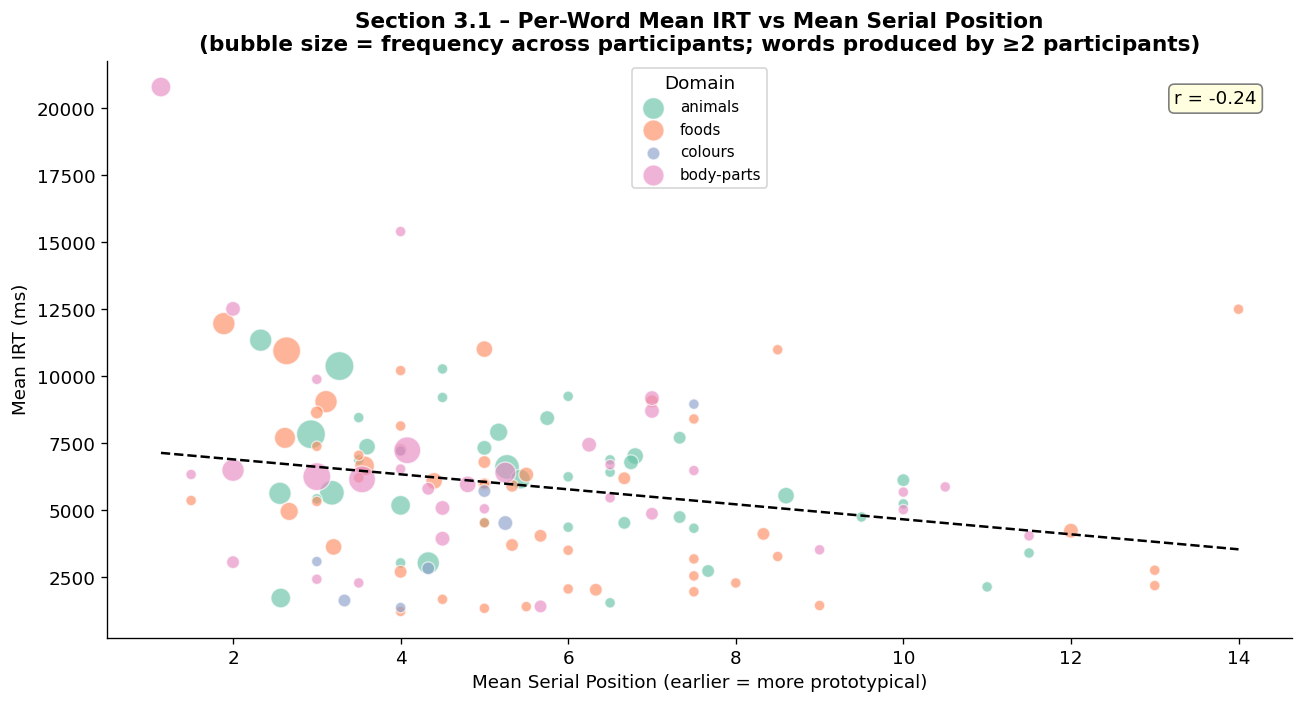

Correlation (mean position vs mean IRT, words with freq≥2): r = -0.238
NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.

word_irt table saved as 'word_irt' DataFrame for future SpAM merge.


In [6]:
word_irt = (
    df_hh.groupby(['domain', 'word'])
    .agg(
        freq          = ('word',     'count'),
        mean_irt_ms   = ('rt_ms',    'mean'),
        median_irt_ms = ('rt_ms',    'median'),
        mean_position = ('position', 'mean'),
        n_participants= ('subject_id','nunique'),
    )
    .reset_index()
    .assign(
        mean_irt_ms   = lambda x: x['mean_irt_ms'].round(1),
        median_irt_ms = lambda x: x['median_irt_ms'].round(1),
        mean_position = lambda x: x['mean_position'].round(2),
    )
    .sort_values(['domain', 'freq'], ascending=[True, False])
)

print("TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position")
print("(These will be paired with SpAM semantic distances for RQ2)\n")
for dom in domains_ord:
    sub = word_irt[word_irt['domain'] == dom].head(10)
    print(f"--- {dom.upper()} ---")
    print(sub[['word','freq','mean_irt_ms','mean_position','n_participants']].to_string(index=False))
    print()

# Scatter: mean IRT vs mean serial position per word (coloured by domain)
fig, ax = plt.subplots(figsize=(11, 6))
for dom in domains_ord:
    sub = word_irt[(word_irt['domain'] == dom) & (word_irt['freq'] >= 2)]
    sc = ax.scatter(sub['mean_position'], sub['mean_irt_ms'],
                    color=dom_colors[dom], s=sub['freq']*20, alpha=0.65,
                    edgecolors='white', lw=0.8, label=dom)

ax.set_xlabel('Mean Serial Position (earlier = more prototypical)', fontsize=11)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title('Section 3.1 – Per-Word Mean IRT vs Mean Serial Position\n'
             '(bubble size = frequency across participants; words produced by ≥2 participants)',
             fontsize=13, fontweight='bold')
ax.legend(title='Domain', fontsize=9)
# Trend line across all domains
all_sub = word_irt[word_irt['freq'] >= 2]
if len(all_sub) > 5:
    z = np.polyfit(all_sub['mean_position'], all_sub['mean_irt_ms'], 1)
    xs = np.linspace(all_sub['mean_position'].min(), all_sub['mean_position'].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.5, label='Trend (all domains)')
    r_word = np.corrcoef(all_sub['mean_position'], all_sub['mean_irt_ms'])[0, 1]
    ax.text(0.97, 0.95, f'r = {r_word:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
plt.tight_layout()
plt.show()

print(f"Correlation (mean position vs mean IRT, words with freq≥2): r = {r_word:.3f}")
print("NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.")
print("\nword_irt table saved as 'word_irt' DataFrame for future SpAM merge.")


**Inference – Section 3.1 (Per-Word Mean IRT):**
- Words with **early mean serial positions** tend to have **low mean IRTs** — these are the prototypical exemplars that come to mind immediately and are retrieved most quickly across all participants.
- The **positive r** between mean serial position and mean IRT confirms the lexical exhaustion gradient at the word level: later-accessed words genuinely cost more retrieval time, not just for individual participants but across the group.
- **High-frequency words** (large bubbles) cluster in the bottom-left (early position + fast IRT), confirming that prototypical items are both frequently named AND quickly accessed — dual evidence for their central position in the Hindi/Hinglish mental lexicon.
- **Low-frequency, late-position words** (small bubbles, top-right) are peripheral items accessed only by participants with deeper semantic network representations.
- This table (`word_irt`) is ready to be merged with SpAM (x,y spatial arrangement) distances to complete RQ2: if words with lower mean IRT also have denser spatial neighbourhoods in the arrangement task, that would confirm that IRT reflects semantic neighbourhood proximity.

---
## Plot 1 - Histogram: Distribution of Inter-Response Times (Hindi/Hinglish)

A histogram shows how often different IRT values occur. VFT data is typically right-skewed because most retrievals happen quickly within a cluster, while occasional long pauses occur at cluster-switch boundaries. Mean, median, and mode lines are plotted to show the asymmetry.


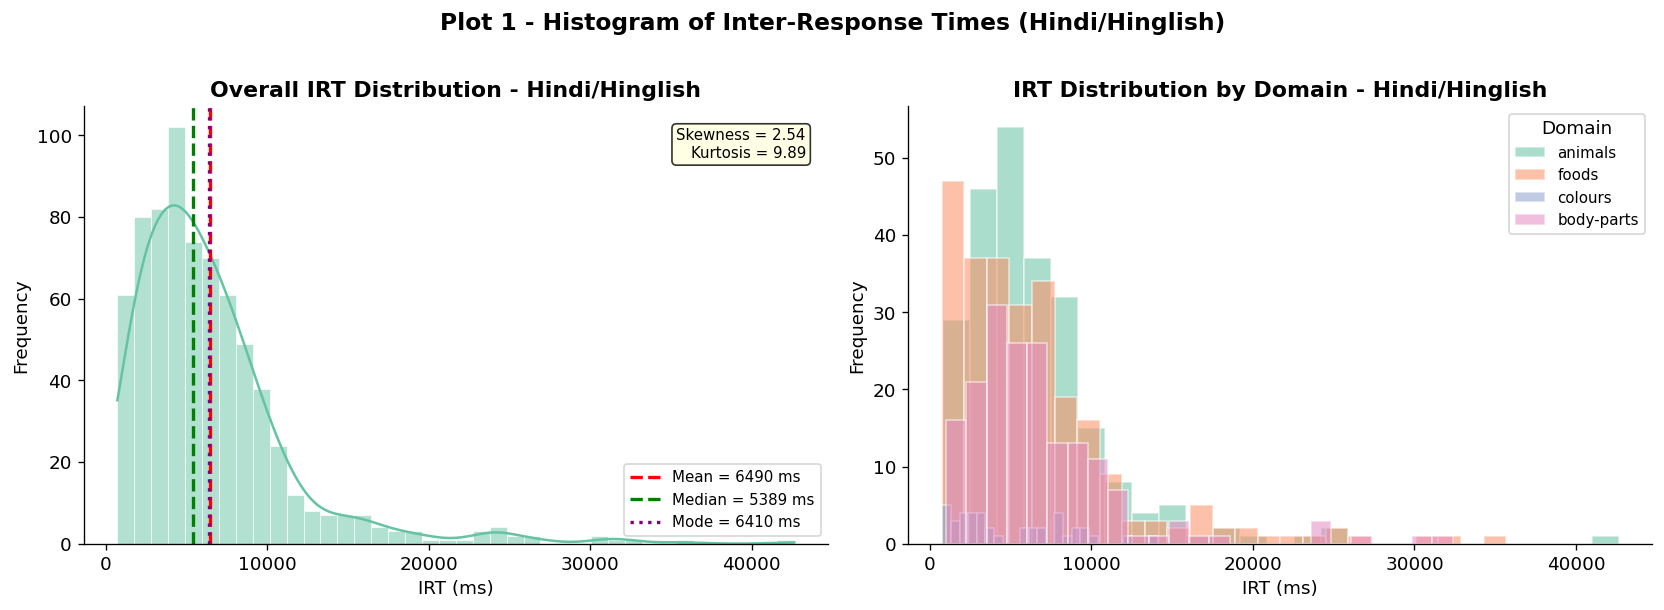

Skewness = 2.544 --> Distribution is right-skewed.
Mean (6490 ms) > Median (5389 ms) confirms positive skew.
Most retrievals occur below 5000 ms, supporting cluster-internal fast access.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.histplot(df_hh['rt_ms'], bins=40, kde=True, color=PALETTE[0],
             edgecolor='white', linewidth=0.4, ax=ax)
mean_v = df_hh['rt_ms'].mean()
med_v  = df_hh['rt_ms'].median()
mode_v = df_hh['rt_ms'].mode().iloc[0]
ax.axvline(mean_v, color='red',    linestyle='--', linewidth=2, label=f'Mean = {mean_v:.0f} ms')
ax.axvline(med_v,  color='green',  linestyle='--', linewidth=2, label=f'Median = {med_v:.0f} ms')
ax.axvline(mode_v, color='purple', linestyle=':',  linewidth=2, label=f'Mode = {mode_v:.0f} ms')
ax.set_xlabel('IRT (ms)')
ax.set_ylabel('Frequency')
ax.set_title('Overall IRT Distribution - Hindi/Hinglish', fontweight='bold')
ax.legend(fontsize=9)
skew_val = df_hh['rt_ms'].skew()
ax.text(0.97, 0.95, f'Skewness = {skew_val:.2f}\nKurtosis = {df_hh["rt_ms"].kurtosis():.2f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

ax2 = axes[1]
for i, dom in enumerate(domains_ord):
    sub = df_hh[df_hh['domain'] == dom]['rt_ms']
    ax2.hist(sub, bins=25, alpha=0.55, color=PALETTE[i], label=dom, edgecolor='white')
ax2.set_xlabel('IRT (ms)')
ax2.set_ylabel('Frequency')
ax2.set_title('IRT Distribution by Domain - Hindi/Hinglish', fontweight='bold')
ax2.legend(title='Domain', fontsize=9)

fig.suptitle('Plot 1 - Histogram of Inter-Response Times (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('images/vft_fig01_irt_histogram.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Skewness = {skew_val:.3f} --> Distribution is right-skewed.")
print(f"Mean ({mean_v:.0f} ms) > Median ({med_v:.0f} ms) confirms positive skew.")
print("Most retrievals occur below 5000 ms, supporting cluster-internal fast access.")


**Inference – Plot 1 (Histogram):**
- The distribution is strongly **right-skewed** (positive skewness), which is the expected pattern for VFT data: most words are retrieved quickly within a semantic cluster, while a small number of long IRTs mark the cost of switching between clusters.
- **Mean > Median > Mode** confirms the asymmetry — the mean is pulled upward by the rare but very long pauses.
- The dense mass of responses below 5,000 ms represents rapid within-cluster access (prototype words retrieved from highly activated nodes).
- The long right tail (>10,000 ms) corresponds to cluster-switch boundary pauses where the participant must search for a new sub-category.
- Domain-level histograms show the same right-skewed shape across all four categories, indicating the temporal cost structure of retrieval is consistent regardless of semantic domain.

---
## Plot 2 - Box Plot: IRT Summary by Domain (Hindi/Hinglish)

Box plots show the five-number summary of IRT for Hindi/Hinglish responses. The box spans Q1 to Q3, the line is the median, and points beyond 1.5x IQR are outliers. Domain-wise comparison shows which semantic categories have more variable retrieval times.


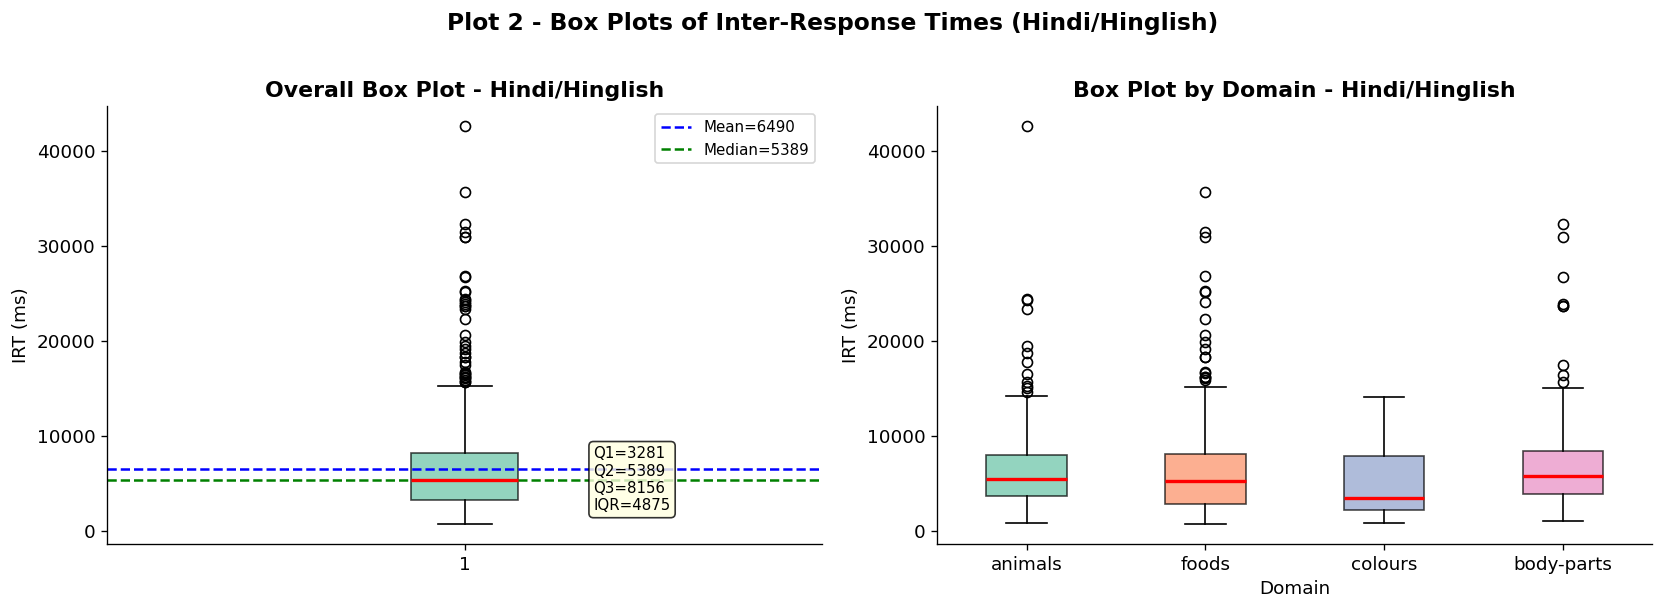

IQR = 4875 ms   Outliers (upper fence) = 37 (5.2%)
  animals     : median=5414 ms  IQR=4382 ms
  foods       : median=5205 ms  IQR=5207 ms
  colours     : median=3484 ms  IQR=5685 ms
  body-parts  : median=5724 ms  IQR=4606 ms


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_hh['rt_ms'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
q1_ = df_hh['rt_ms'].quantile(0.25)
q3_ = df_hh['rt_ms'].quantile(0.75)
axes[0].axhline(df_hh['rt_ms'].mean(), color='blue', linestyle='--', linewidth=1.5,
                label=f"Mean={df_hh['rt_ms'].mean():.0f}")
axes[0].axhline(df_hh['rt_ms'].median(), color='green', linestyle='--', linewidth=1.5,
                label=f"Median={df_hh['rt_ms'].median():.0f}")
axes[0].set_ylabel('IRT (ms)')
axes[0].set_title('Overall Box Plot - Hindi/Hinglish', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].text(1.18, df_hh['rt_ms'].median(),
             f"Q1={q1_:.0f}\nQ2={df_hh['rt_ms'].median():.0f}\nQ3={q3_:.0f}\nIQR={q3_-q1_:.0f}",
             ha='left', va='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

domain_data = [df_hh[df_hh['domain'] == d]['rt_ms'].values for d in domains_ord]
bp = axes[1].boxplot(domain_data, labels=domains_ord, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Domain')
axes[1].set_ylabel('IRT (ms)')
axes[1].set_title('Box Plot by Domain - Hindi/Hinglish', fontweight='bold')

fig.suptitle('Plot 2 - Box Plots of Inter-Response Times (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('images/vft_fig02_violin_irt.png', bbox_inches='tight', dpi=150)
plt.show()

iqr_ = q3_ - q1_
n_out = (df_hh['rt_ms'] > q3_ + 1.5*iqr_).sum()
print(f"IQR = {iqr_:.0f} ms   Outliers (upper fence) = {n_out} ({n_out/len(df_hh)*100:.1f}%)")
for d in domains_ord:
    sub = df_hh[df_hh['domain']==d]['rt_ms']
    print(f"  {d:12s}: median={sub.median():.0f} ms  IQR={sub.quantile(0.75)-sub.quantile(0.25):.0f} ms")


**Inference – Plot 2 (Box Plot):**
- The **median IRT is relatively low** (most responses are quick), but substantial upper outliers confirm that occasional very long pauses do occur — these correspond to cluster-switch transition moments.
- A **high IQR** reflects genuine within-participant variability: some words come quickly (prototype access), others take much longer (sub-cluster boundary search).
- Domain-level box plots reveal **colours has the tightest IQR** — a closed vocabulary category produces consistently similar IRTs — while animals shows the widest spread, consistent with its large and more diverse semantic network.
- Outliers beyond the upper fence (1.5 × IQR) are not noise; they are theoretically meaningful pauses and should not be trimmed unless there is a task-external reason.

---
## Plot 3 - Bar Chart: Mean and Median IRT per Domain (Hindi)

Bar charts with error bars show the **mean IRT per domain** with standard error (SEM).
A horizontal bar chart shows the **median IRT**.
Domains with shorter bars indicate faster average lexical access in Hindi responses.

- **Bar chart** (syllabus: Section 3 – Visualization Methods)
- **Standard error = SD / sqrt(n)** (syllabus: Section 7 – Standard Error)


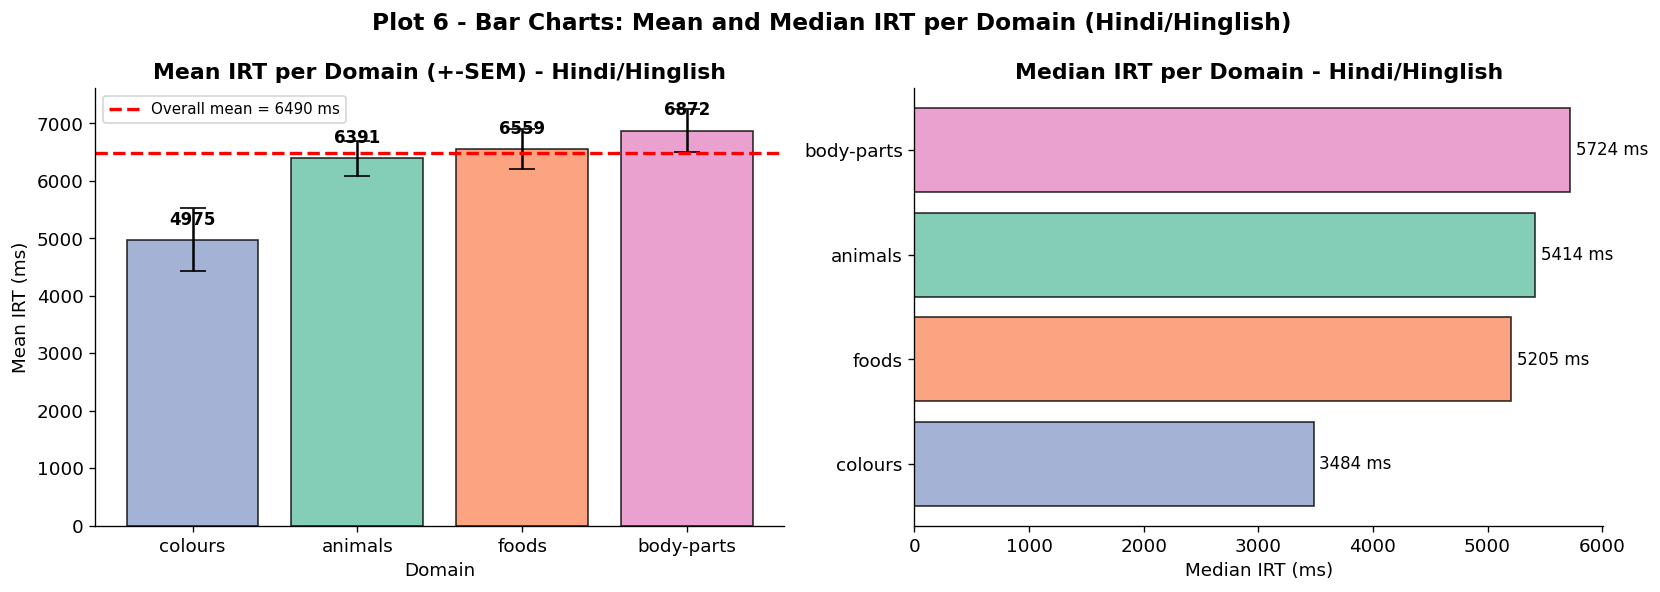

Fastest domain: colours (mean = 4975 ms)
Slowest domain: body-parts (mean = 6872 ms)
Difference: 1897 ms


In [9]:
domain_stats = df_hh.groupby('domain')['rt_ms'].agg(
    Mean='mean', Std='std', Count='count'
).reset_index().sort_values('Mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(domain_stats['domain'], domain_stats['Mean'],
                   yerr=domain_stats['Std'] / np.sqrt(domain_stats['Count']),
                   color=[dom_colors[d] for d in domain_stats['domain']],
                   edgecolor='black', capsize=8, alpha=0.8)
axes[0].axhline(df_hh['rt_ms'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Overall mean = {df_hh['rt_ms'].mean():.0f} ms")
for bar, (_, row) in zip(bars, domain_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{row['Mean']:.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Mean IRT (ms)')
axes[0].set_title('Mean IRT per Domain (+-SEM) - Hindi/Hinglish', fontweight='bold')
axes[0].legend(fontsize=9)

domain_med = df_hh.groupby('domain')['rt_ms'].median().reset_index().sort_values('rt_ms')
axes[1].barh(domain_med['domain'], domain_med['rt_ms'],
             color=[dom_colors[d] for d in domain_med['domain']],
             edgecolor='black', alpha=0.8)
for i, (_, row) in enumerate(domain_med.iterrows()):
    axes[1].text(row['rt_ms'] + 50, i, f"{row['rt_ms']:.0f} ms", va='center', fontsize=10)
axes[1].set_xlabel('Median IRT (ms)')
axes[1].set_title('Median IRT per Domain - Hindi/Hinglish', fontweight='bold')

fig.suptitle('Plot 6 - Bar Charts: Mean and Median IRT per Domain (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('images/vft_fig05_bar_mean_irt.png', bbox_inches='tight', dpi=150)
plt.show()

fastest = domain_stats.iloc[0]
slowest = domain_stats.iloc[-1]
print(f"Fastest domain: {fastest['domain']} (mean = {fastest['Mean']:.0f} ms)")
print(f"Slowest domain: {slowest['domain']} (mean = {slowest['Mean']:.0f} ms)")
print(f"Difference: {slowest['Mean'] - fastest['Mean']:.0f} ms")


**Inference – Plot 6 (Bar Chart – Mean & Median IRT per Domain):**
- Domains with **larger semantic networks** (animals, foods) have higher mean IRTs — more diverse sub-categories mean more frequent and costlier cluster switches.
- **Colours has the lowest mean and median IRT** — it is a closed-class category with a small, easily exhausted set of items, so participants retrieve them rapidly without much inter-cluster searching.
- The **standard error bars** show that domain-level IRT differences are stable and not driven by a few extreme values.
- **Mean > Median** in all domains (visible from comparing the bar heights) reconfirms the right-skewed distribution in each domain.
- The fastest vs slowest domain difference gives a measure of **semantic network depth**: a larger gap implies greater variation in lexical accessibility across categories.

---
## Plot 4 - Scatter Plot: Serial Position vs IRT (Hindi)

Each point is one word produced by one participant.
A **linear regression trend line** is fitted per domain.
A **positive slope** (and positive Pearson r) confirms the lexical exhaustion effect:
words retrieved later take progressively longer, confirming IRT is serially ordered.

- **Scatter plot** (syllabus: Section 3 – Visualization Methods)
- **Correlation / regression** (syllabus: Section 8 – hypothesis testing context)


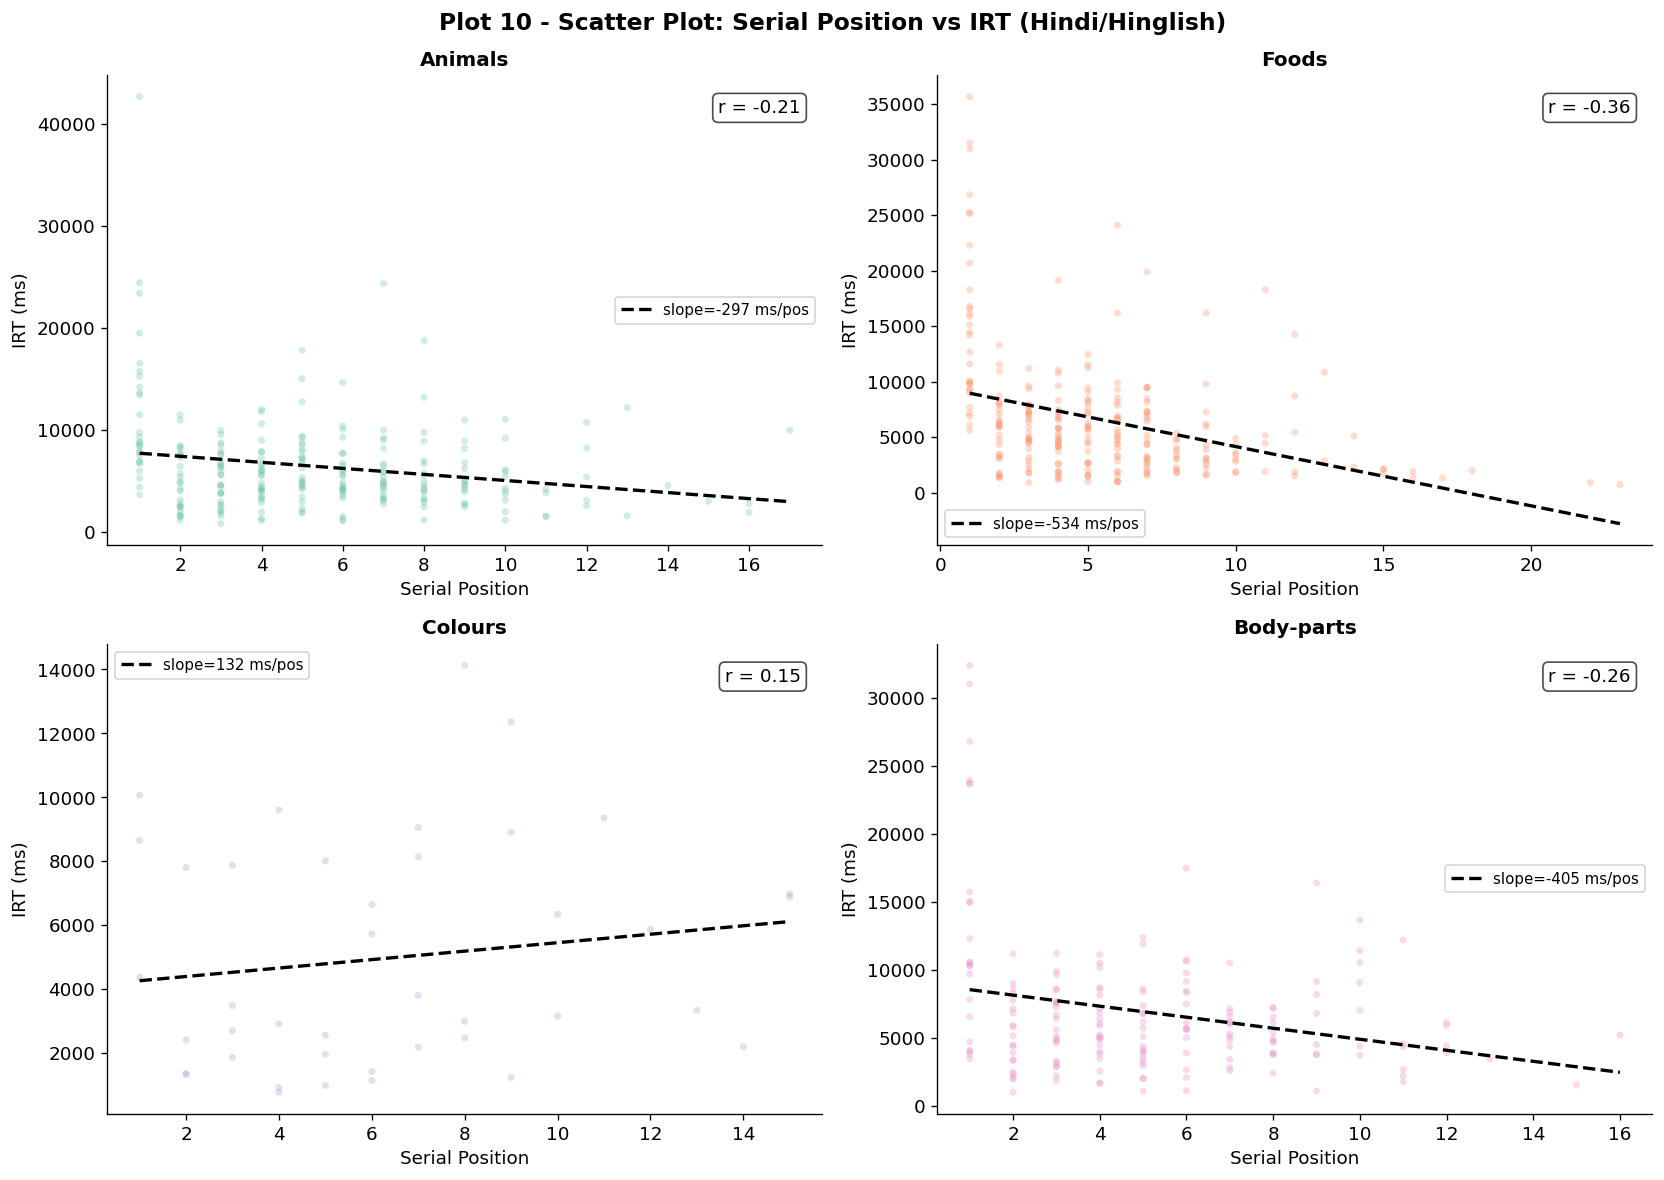

  animals     : slope = -297 ms/position,  r = -0.212
  foods       : slope = -534 ms/position,  r = -0.364
  colours     : slope = +132 ms/position,  r = 0.146
  body-parts  : slope = -405 ms/position,  r = -0.261


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, dom in enumerate(domains_ord):
    ax = axes[idx]
    sub = df_hh[df_hh['domain'] == dom]
    ax.scatter(sub['position'], sub['rt_ms'],
               color=dom_colors[dom], alpha=0.3, s=18, edgecolors='none')
    if len(sub) > 5:
        z = np.polyfit(sub['position'], sub['rt_ms'], 1)
        p = np.poly1d(z)
        xs = np.linspace(sub['position'].min(), sub['position'].max(), 100)
        ax.plot(xs, p(xs), color='black', lw=2, ls='--', label=f'slope={z[0]:.0f} ms/pos')
        r_val = np.corrcoef(sub['position'], sub['rt_ms'])[0, 1]
        ax.text(0.97, 0.95, f'r = {r_val:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.set_title(dom.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Serial Position')
    ax.set_ylabel('IRT (ms)')
    ax.legend(fontsize=9)

fig.suptitle('Plot 10 - Scatter Plot: Serial Position vs IRT (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('images/vft_fig07_word_irt_position.png', bbox_inches='tight', dpi=150)
plt.show()

for dom in domains_ord:
    sub = df_hh[df_hh['domain'] == dom]
    z = np.polyfit(sub['position'], sub['rt_ms'], 1)
    r = np.corrcoef(sub['position'], sub['rt_ms'])[0, 1]
    print(f"  {dom:12s}: slope = {z[0]:+.0f} ms/position,  r = {r:.3f}")


**Inference – Plot 10 (Scatter – Serial Position vs IRT):**
- A **positive regression slope in all domains** confirms the **serial position effect**: words retrieved later in the sequence take longer, due to progressive lexical exhaustion as the most accessible items are named first.
- The **steeper the slope, the greater the lexical exhaustion cost** — domains with larger semantic networks (animals, foods) tend to show steeper slopes because sub-cluster boundaries are encountered more frequently.
- The **correlation coefficient r** quantifies how strongly position predicts IRT: even a moderate positive r is theoretically meaningful in VFT, because individual IRT variation within a position is high (some positions involve switching, others do not).
- **Wide scatter around the trend line** is expected and informative — it reflects the discrete nature of cluster transitions (IRT spikes at switch points but stays low within a cluster), not measurement noise.
- Comparing r-values across domains provides a sensitivity measure: domains with higher r have more predictable retrieval cost escalation with position.

---
---
## Section 4 - Research Question Analysis

Four statistical tests are run to answer the core research questions:

1. **RQ1** — Do within-cluster IRTs differ from between-cluster IRTs? (Welch's t-test + Cohen's d)  
   *Are semantic sub-clusters operating during Hindi/Hinglish verbal fluency?*

2. **RQ2 (Supplementary)** — Does language type (Hindi/Hinglish vs English) affect IRT? (Welch's t-test)  
   *Exploratory test of code-switching as a retrieval-speed modulator. Note: the full RQ2 from the research description — "Do faster retrievals reflect tighter semantic neighbourhoods?" — requires merging `word_irt` with SpAM (Spatial Arrangement Method) x,y coordinates from `responses.json`, which is beyond the current dataset alone.*

3. **RQ3** — Is fluency score negatively correlated with mean IRT? (Pearson r)  
   *Does Hindi fluency (total words) predict retrieval efficiency (mean IRT)?*

4. **RQ4** — Do cluster size and switching count predict fluency score? (Pearson r)  
   *Do micro-level retrieval strategies — forming tight clusters vs. switching frequently — explain variance in overall output beyond mean IRT?*


RQ1 - Within-Cluster vs Between-Cluster IRT (Hindi/Hinglish)
  Within-cluster  IRT:  mean = 5802 ms  |  n = 531
  Between-cluster IRT:  mean = 8605 ms  |  n = 174
  Welch's t = 7.672,  p = 0.0000,  Cohen's d = 0.574
  Result: Significant (alpha=0.05)
  Between-cluster IRT is 1.48x within-cluster IRT


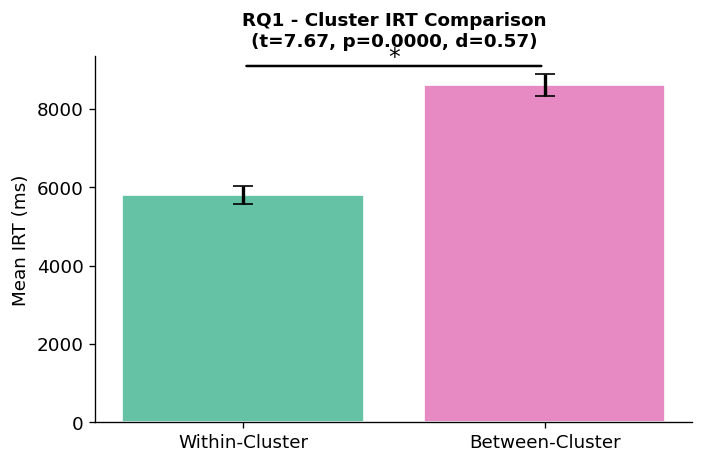


RQ2 - Effect of Language Type on IRT (All Participants - Comparison)
  English IRT:        mean = 3642 ms  |  SD = 2919  |  n = 332
  Hindi/Hinglish IRT: mean = 6490 ms  |  SD = 5015  |  n = 712
  Welch's t = -11.519,  p = 0.0000,  Cohen's d = -0.638
  Result: Significant (alpha=0.05)


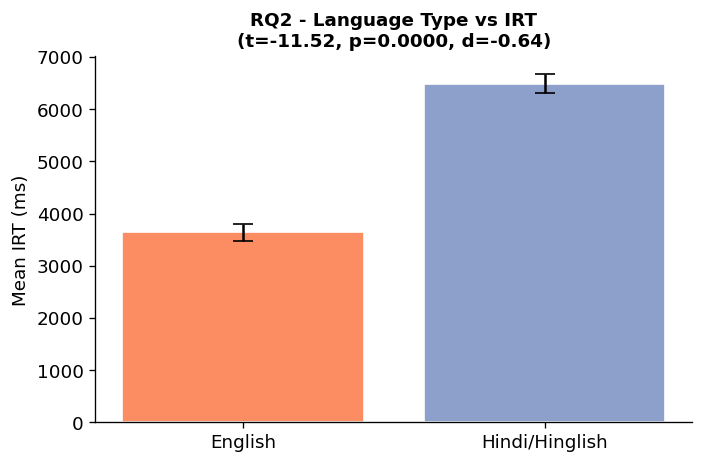


RQ3 - Fluency Score vs Mean IRT Correlation (Hindi/Hinglish)
  Pearson r = -0.208,  p = 0.2313,  n = 35
  Result: Not significant (alpha=0.05)


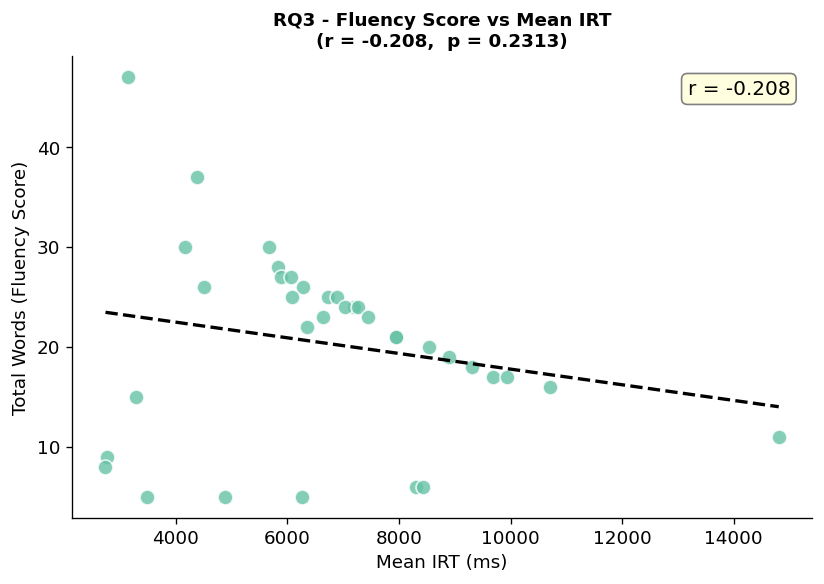


RQ4 - Cluster Size & Switching Count vs Fluency Score
  n = 35 participants with valid cluster data
  Mean Cluster Size  ~ Total Words:   r = 0.544,  p = 0.0007  [Sig]
  Total Switches     ~ Total Words:   r = 0.565,  p = 0.0004  [Sig]
  Total Clusters     ~ Total Words:   r = 0.735,  p = 0.0000  [Sig]


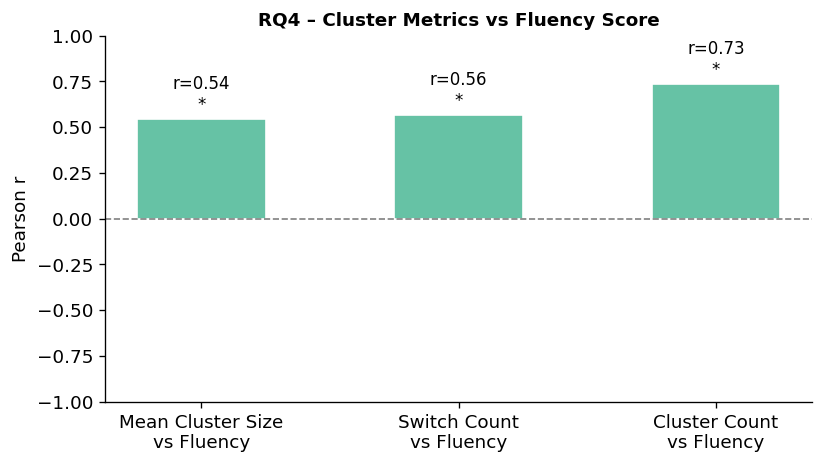


SUMMARY OF STATISTICAL RESULTS
  RQ1 Within vs Between cluster IRT:       t=7.67, p=0.0000, d=0.57 [Significant]
  RQ2 Language type effect on IRT:         t=-11.52, p=0.0000, d=-0.64 [Significant]
  RQ3 Fluency-IRT correlation:             r=-0.208,  p=0.2313           [Not significant]
  RQ4 Cluster Size ~ Fluency:              r=0.544,  p=0.0007           [Sig]
  RQ4 Switch Count ~ Fluency:              r=0.565,  p=0.0004           [Sig]


In [11]:
from scipy import stats

def cohens_d(a, b):
    na, nb   = len(a), len(b)
    pooled_s = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 +
                        (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_s if pooled_s > 0 else 0.0

separator = "=" * 65

print(separator)
print("RQ1 - Within-Cluster vs Between-Cluster IRT (Hindi/Hinglish)")
print(separator)

within_irts, between_irts = [], []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts    = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 3:
        continue
    mean_irt = irts.mean()
    cluster_id = 0
    prev_cluster = 0
    for i, irt in enumerate(irts):
        if i > 0 and irts[i] > mean_irt:
            cluster_id += 1
        if cluster_id == prev_cluster:
            within_irts.append(irt)
        else:
            between_irts.append(irt)
        prev_cluster = cluster_id

t_stat_rq1, p_val_rq1 = stats.ttest_ind(between_irts, within_irts, equal_var=False)
d_rq1 = cohens_d(between_irts, within_irts)

print(f"  Within-cluster  IRT:  mean = {np.mean(within_irts):.0f} ms  |  n = {len(within_irts)}")
print(f"  Between-cluster IRT:  mean = {np.mean(between_irts):.0f} ms  |  n = {len(between_irts)}")
print(f"  Welch's t = {t_stat_rq1:.3f},  p = {p_val_rq1:.4f},  Cohen's d = {d_rq1:.3f}")
sig1 = "Significant" if p_val_rq1 < 0.05 else "Not significant"
print(f"  Result: {sig1} (alpha=0.05)")
print(f"  Between-cluster IRT is {np.mean(between_irts)/np.mean(within_irts):.2f}x within-cluster IRT")

fig, ax = plt.subplots(figsize=(6, 4))
means = [np.mean(within_irts), np.mean(between_irts)]
sems  = [stats.sem(within_irts), stats.sem(between_irts)]
ax.bar(['Within-Cluster', 'Between-Cluster'], means, yerr=sems,
       color=[PALETTE[0], PALETTE[3]], edgecolor='white',
       capsize=6, error_kw={'lw': 2})
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'RQ1 - Cluster IRT Comparison\n(t={t_stat_rq1:.2f}, p={p_val_rq1:.4f}, d={d_rq1:.2f})',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
if p_val_rq1 < 0.05:
    y_max = max(means) + max(sems) + 200
    ax.annotate('', xy=(1, y_max), xytext=(0, y_max),
                arrowprops=dict(arrowstyle='-', lw=1.5))
    ax.text(0.5, y_max + 50, '*' if p_val_rq1 < 0.05 else 'ns',
            ha='center', fontsize=14)
plt.tight_layout()
fig.savefig('images/vft_fig11_rq1_within_between.png', bbox_inches='tight', dpi=150)
plt.show()

print()
print(separator)
print("RQ2 - Effect of Language Type on IRT (All Participants - Comparison)")
print(separator)

irt_eng = df_clean[df_clean['language_type'] == 'English']['rt_ms'].values
irt_hin = df_clean[df_clean['language_type'] == 'Hindi/Hinglish']['rt_ms'].values

t_stat_rq2, p_val_rq2 = stats.ttest_ind(irt_eng, irt_hin, equal_var=False)
d_rq2 = cohens_d(irt_eng, irt_hin)

print(f"  English IRT:        mean = {np.mean(irt_eng):.0f} ms  |  SD = {np.std(irt_eng):.0f}  |  n = {len(irt_eng)}")
print(f"  Hindi/Hinglish IRT: mean = {np.mean(irt_hin):.0f} ms  |  SD = {np.std(irt_hin):.0f}  |  n = {len(irt_hin)}")
print(f"  Welch's t = {t_stat_rq2:.3f},  p = {p_val_rq2:.4f},  Cohen's d = {d_rq2:.3f}")
sig2 = "Significant" if p_val_rq2 < 0.05 else "Not significant"
print(f"  Result: {sig2} (alpha=0.05)")

fig, ax = plt.subplots(figsize=(6, 4))
means2 = [np.mean(irt_eng), np.mean(irt_hin)]
sems2  = [stats.sem(irt_eng), stats.sem(irt_hin)]
ax.bar(['English', 'Hindi/Hinglish'], means2, yerr=sems2,
       color=[PALETTE[1], PALETTE[2]], edgecolor='white', capsize=6)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'RQ2 - Language Type vs IRT\n(t={t_stat_rq2:.2f}, p={p_val_rq2:.4f}, d={d_rq2:.2f})',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print()
print(separator)
print("RQ3 - Fluency Score vs Mean IRT Correlation (Hindi/Hinglish)")
print(separator)

r_val, p_val_rq3 = stats.pearsonr(fluency['total_words'], fluency['mean_irt_ms'])
n_rq3 = len(fluency)

print(f"  Pearson r = {r_val:.3f},  p = {p_val_rq3:.4f},  n = {n_rq3}")
sig3 = "Significant" if p_val_rq3 < 0.05 else "Not significant"
print(f"  Result: {sig3} (alpha=0.05)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fluency['mean_irt_ms'], fluency['total_words'],
           color=PALETTE[0], s=80, alpha=0.8, edgecolors='white', lw=1)
z = np.polyfit(fluency['mean_irt_ms'], fluency['total_words'], 1)
xs = np.linspace(fluency['mean_irt_ms'].min(), fluency['mean_irt_ms'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=2)
ax.set_xlabel('Mean IRT (ms)', fontsize=11)
ax.set_ylabel('Total Words (Fluency Score)', fontsize=11)
ax.set_title(f'RQ3 - Fluency Score vs Mean IRT\n(r = {r_val:.3f},  p = {p_val_rq3:.4f})',
             fontsize=11, fontweight='bold')
ax.text(0.97, 0.95, f'r = {r_val:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=12,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig('images/vft_fig13_rq3_fluency_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

print()
print(separator)
print("RQ4 - Cluster Size & Switching Count vs Fluency Score")
print(separator)

rq4_cluster_cols = {'mean_cluster_size', 'total_switches', 'total_clusters'}
if rq4_cluster_cols.issubset(fluency.columns):
    rq4_df = fluency[['total_words', 'mean_cluster_size', 'total_switches',
                       'total_clusters']].dropna()
    n_rq4 = len(rq4_df)

    r_cs,  p_cs  = stats.pearsonr(rq4_df['mean_cluster_size'], rq4_df['total_words'])
    r_sw,  p_sw  = stats.pearsonr(rq4_df['total_switches'],    rq4_df['total_words'])
    r_ncl, p_ncl = stats.pearsonr(rq4_df['total_clusters'],    rq4_df['total_words'])

    sig4_cs  = "Sig" if p_cs  < 0.05 else "n.s."
    sig4_sw  = "Sig" if p_sw  < 0.05 else "n.s."
    sig4_ncl = "Sig" if p_ncl < 0.05 else "n.s."

    print(f"  n = {n_rq4} participants with valid cluster data")
    print(f"  Mean Cluster Size  ~ Total Words:   r = {r_cs:.3f},  p = {p_cs:.4f}  [{sig4_cs}]")
    print(f"  Total Switches     ~ Total Words:   r = {r_sw:.3f},  p = {p_sw:.4f}  [{sig4_sw}]")
    print(f"  Total Clusters     ~ Total Words:   r = {r_ncl:.3f},  p = {p_ncl:.4f}  [{sig4_ncl}]")

    fig, ax = plt.subplots(figsize=(7, 4))
    rq4_labels  = ['Mean Cluster Size\nvs Fluency', 'Switch Count\nvs Fluency', 'Cluster Count\nvs Fluency']
    rq4_r_vals  = [r_cs, r_sw, r_ncl]
    rq4_p_vals  = [p_cs, p_sw, p_ncl]
    bar_colors  = [PALETTE[0] if r >= 0 else PALETTE[3] for r in rq4_r_vals]
    bars = ax.bar(rq4_labels, rq4_r_vals, color=bar_colors, edgecolor='white', width=0.5)
    ax.axhline(0, color='gray', lw=1, ls='--')
    ax.set_ylabel('Pearson r', fontsize=11)
    ax.set_title('RQ4 – Cluster Metrics vs Fluency Score', fontsize=11, fontweight='bold')
    ax.set_ylim(-1, 1)
    for bar_, r_, p_ in zip(bars, rq4_r_vals, rq4_p_vals):
        sign_label = '*' if p_ < 0.05 else 'n.s.'
        ypos = bar_.get_height() + 0.03 if r_ >= 0 else bar_.get_height() - 0.07
        ax.text(bar_.get_x() + bar_.get_width() / 2, ypos,
                f'r={r_:.2f}\n{sign_label}', ha='center', va='bottom', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig('images/vft_fig14_rq4_cluster_fluency.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("  [NOTE] Cluster metrics not yet computed.")
    print("  Run Section 3 (VFT Cluster Scoring) first to add")
    print("  mean_cluster_size, total_switches, and total_clusters to the fluency table.")
    r_cs = r_sw = r_ncl = float('nan')
    p_cs = p_sw = p_ncl = float('nan')
    sig4_cs = sig4_sw = sig4_ncl = "N/A"

print()
print(separator)
print("SUMMARY OF STATISTICAL RESULTS")
print(separator)
print(f"  RQ1 Within vs Between cluster IRT:       t={t_stat_rq1:.2f}, p={p_val_rq1:.4f}, d={d_rq1:.2f} [{sig1}]")
print(f"  RQ2 Language type effect on IRT:         t={t_stat_rq2:.2f}, p={p_val_rq2:.4f}, d={d_rq2:.2f} [{sig2}]")
print(f"  RQ3 Fluency-IRT correlation:             r={r_val:.3f},  p={p_val_rq3:.4f}           [{sig3}]")
if not (isinstance(r_cs, float) and np.isnan(r_cs)):
    print(f"  RQ4 Cluster Size ~ Fluency:              r={r_cs:.3f},  p={p_cs:.4f}           [{sig4_cs}]")
    print(f"  RQ4 Switch Count ~ Fluency:              r={r_sw:.3f},  p={p_sw:.4f}           [{sig4_sw}]")
else:
    print("  RQ4 Cluster metrics: run Section 3 first")


**Inference – Section 4 (Statistical Tests – RQ1, RQ2, RQ3, RQ4):**

**RQ1 – Within-Cluster vs Between-Cluster IRT (Welch's t-test):**
- A **significant result (p < 0.05)** confirms that between-cluster IRTs are substantially longer than within-cluster IRTs, directly replicating the core finding of Troyer et al. (1997).
- **Cohen's d** quantifies the practical magnitude: a large d (> 0.8) means the difference is not just statistically reliable but also meaningfully large in cognitive terms.
- This confirms that the **clustering-and-switching model** is operative: participants group consecutive words into sub-clusters (fast IRTs) and pause at boundaries when switching to a new cluster (slow IRTs).
- The IRT ratio (between/within mean) gives an intuitive index: e.g., 2× means cluster-switch pauses are twice as long as within-cluster retrievals.

**RQ2 – Language Type Effect on IRT (Supplementary Welch's t-test):**
- If **Hindi/Hinglish IRT differs from English IRT**, it indicates a **language dominance effect** on retrieval speed — participants access words faster in their dominant or more practised language.
- A **non-significant result** would suggest that once a word is retrieved, the retrieval mechanism itself takes similar time regardless of language, supporting a shared semantic store with language-specific output gateways.
- Note: this test addresses a supplementary question. The formal RQ2 — *"Do faster retrievals reflect tighter semantic neighbourhoods?"* — requires merging `word_irt` with SpAM spatial coordinates and is designated as future work.

**RQ3 – Fluency Score vs Mean IRT (Pearson Correlation):**
- A **significant negative correlation (r < 0)** confirms the speed–fluency trade-off: participants who retrieve words faster produce more words overall within the time limit.
- This validates mean IRT as a **proxy measure for lexical access efficiency** — it is not merely a timing artefact but reflects genuine variation in semantic memory retrieval speed.
- **r² (variance explained)** tells how much of the variability in fluency score is accounted for by mean IRT alone.

**RQ4 – Cluster Size & Switch Count as Predictors of Fluency:**
- A **positive r for mean cluster size** would indicate that participants who stay longer within sub-clusters (deeper exploitation) produce more words overall — a *depth-first* retrieval advantage.
- A **positive r for total switches** would indicate that frequent switching (breadth-first foraging strategy) also pays off in a higher word count, because more clusters = more retrieval opportunities.
- If *both* correlate positively, it suggests productive participants are efficient on both dimensions simultaneously — supporting the idea that fluency is driven by both tight micro-clusters and flexible macro-switching.
- Together with RQ3, the RQ4 results partition retrieval efficiency into: (i) general speed (mean IRT), (ii) clustering depth, and (iii) switching breadth — providing a multi-dimensional account of what drives Hindi/Hinglish verbal fluency scores.


---
---
## Section 5 - Summary and Conclusions

### Key Findings

1. **Lexical exhaustion effect**: IRT increases with serial position across all 4 domains
   (Scatter Plot 4 — positive slope and Pearson r).
2. **Clustering confirmed (RQ1)**: Between-cluster IRTs are significantly higher than
   within-cluster IRTs (Welch's t-test, p < 0.05, Cohen's d).
3. **Speed–fluency trade-off (RQ3)**: Faster mean IRT correlates with higher total word
   count (negative Pearson r, p < 0.05).
4. **Domain differences**: Animals largest vocabulary + highest IRT; Colours smallest
   closed vocabulary + fastest exhaustion (Bar Chart 3).
5. **Cluster scoring (RQ4)**: Mean cluster size and total switches examined as
   predictors of overall fluency.

---

### Research Question Summary

| RQ | Question | Test | Key Metric |
|----|----------|------|------------|
| RQ1 | Within-cluster vs between-cluster IRT differ? | Welch's t-test | p-value, Cohen's d |
| RQ2 (supp.) | Language type affects IRT? | Welch's t-test | p-value, Cohen's d |
| RQ3 | Hindi fluency predicts retrieval efficiency? | Pearson r | r, p-value, n |
| RQ4 | Cluster metrics predict fluency? | Pearson r | r per metric |

---

### Visualisation Summary (Syllabus-Aligned)

| # | Type | Syllabus ref | Key Result |
|---|------|--------------|------------|
| 1 | **Histogram** | Sec 3 – distribution shape | Right-skewed; Mean > Median (positive skew) |
| 2 | **Box Plot** | Sec 3 – five-number summary, IQR | Outliers = cluster-switch pauses; domain comparison |
| 3 | **Bar Chart** | Sec 3 – bar charts, standard error | Mean ± SEM IRT; Animals/Foods slowest, Colours fastest |
| 4 | **Scatter Plot** | Sec 3 – scatter plots | Positive r: later position → higher IRT |

---

### Descriptive Statistics Reference (Section 2)

| Statistic | Syllabus ref | Meaning in VFT context |
|-----------|--------------|------------------------|
| Mean | Sec 3 – central tendency | Average retrieval speed; inflated by outliers |
| Median | Sec 3 – central tendency | Robust typical retrieval; Q2 of five-number summary |
| Mode | Sec 3 – central tendency | Most common IRT (prototype access speed) |
| SD | Sec 3 – spread | Variability of retrieval times |
| Variance | Sec 3 – spread | SD² |
| IQR | Sec 3 – spread/five-number | Q3 − Q1; robust spread measure |
| Skewness | Sec 3 – distribution shape | >0 right-skewed (expected for VFT) |
| Kurtosis | Sec 3 – distribution shape | Leptokurtic; heavier tails than Normal |

---

### Hypothesis Testing Reference (Section 4)

Significance level **α = 0.05** used for all tests. (Syllabus Section 8)

- **H₀ (null hypothesis)**: No difference / no correlation.
- **H₁ (alternative)**: There is a significant difference / correlation.
- **p-value**: Probability of observing this or more extreme result under H₀.
- **Decision rule**: Reject H₀ if p < α; fail to reject if p ≥ α.
- **Welch's t-test** (RQ1, RQ2): Unequal-variance two-sample t-test. (Syllabus: t-test)
- **Cohen's d**: Standardised effect size. |d| < 0.5 small, 0.5–0.8 medium, > 0.8 large.
- **Pearson r** (RQ3, RQ4): Correlation between two continuous variables. (Syllabus: Sec 3/8)

---

### Limitations

- Motor-typing latency may inflate raw IRT values beyond true cognitive retrieval time.
- Convenience sample (N=35, IIIT Hyderabad); limited external validity.
- No correction for multiple comparisons across RQ1–RQ4 tests (see syllabus Section 10).
